# 04 Evaluated Pricing

This notebook combines Treasury discounting and peer-implied spreads to produce model prices, residuals, and review flags.

At this stage, I compare each observed bond level with the peer-implied level. The main output is the residual and whether it is large enough to review.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import matplotlib.pyplot as plt

from src.evaluator import build_evaluation_outputs

In [3]:
evaluation_table, comp_table = build_evaluation_outputs(
    analytics_path=PROJECT_ROOT / "outputs" / "bond_analytics.csv",
    bond_universe_path=PROJECT_ROOT / "data" / "raw" / "bond_universe.csv",
    treasury_curve_path=PROJECT_ROOT / "data" / "raw" / "treasury_curve.csv",
    max_comps=3,
)
evaluation_table

,bond_id,issuer,evaluation_date,maturity_date,coupon_rate,clean_price,accrued_interest,dirty_price,ytm,spread_to_curve,...,face_value,fair_spread,comp_count,comp_support_score,comp_ids,fair_model_dirty_price,price_residual,spread_residual_bps,review_flag,review_reason
0,AMZN_2031_425,Amazon.com Inc,2026-04-06,2031-03-13,0.04250,99.36,0.277174,99.637174,0.043957,0.004108,...,100,0.005692,3,2.871374,"AMZN_2036_488, META_2030_420, PFE_2033_475",98.934947,0.702227,-15.838912,Review,moderate spread residual; moderate price residual
1,AMZN_2036_488,Amazon.com Inc,2026-04-06,2036-03-13,0.04875,99.31,0.317935,99.627935,0.049626,0.006153,...,100,0.005358,3,2.861443,"AMZN_2031_425, PFE_2033_475, META_2035_488",100.255333,-0.627398,7.948876,Review,moderate price residual
2,F_2030_400,Ford Motor Credit Company LLC,2026-04-06,2030-11-13,0.04000,93.49,1.591160,95.081160,0.056206,0.016347,...,100,0.019408,3,0.881553,"F_2033_713, AMZN_2031_425, META_2030_420",93.897575,1.183585,-30.614113,High Review,large spread residual; large price residual; w...
3,F_2033_713,Ford Motor Credit Company LLC,2026-04-06,2033-11-07,0.07125,105.39,2.952348,108.342348,0.062186,0.020095,...,100,0.015907,3,-0.832518,"F_2030_400, PFE_2033_475, AMZN_2036_488",110.996402,-2.654054,41.888878,High Review,large spread residual; large price residual; w...
4,META_2030_420,Meta Platforms Inc,2026-04-06,2030-11-15,0.04200,99.17,1.647514,100.817514,0.043974,0.004290,...,100,0.006341,3,2.004952,"META_2035_488, AMZN_2031_425, PFE_2033_475",99.963817,0.853696,-20.510850,High Review,large spread residual; moderate price residual
5,META_2035_488,Meta Platforms Inc,2026-04-06,2035-11-15,0.04875,98.46,1.912293,100.372293,0.050777,0.007494,...,100,0.004878,3,2.029900,"META_2030_420, AMZN_2036_488, PFE_2033_475",102.379862,-2.007569,26.156355,High Review,large spread residual; large price residual
6,PFE_2033_475,Pfizer Investment Enterprises Pte,2026-04-06,2033-05-19,0.04750,99.71,1.810773,101.520773,0.047977,0.006182,...,100,0.005260,3,1.368539,"AMZN_2036_488, AMZN_2031_425, META_2035_488",102.081786,-0.561013,9.222071,Review,moderate price residual; weak comp support
7,PFE_2053_530,Pfizer Investment Enterprises Pte,2026-04-06,2053-05-19,0.05300,93.75,2.020442,95.770442,0.057573,0.010392,...,100,0.006610,3,-10.452428,"PFE_2033_475, AMZN_2036_488, META_2035_488",100.833873,-5.063431,37.824855,High Review,large spread residual; large price residual; w...


In [4]:
evaluation_view = evaluation_table[
    [
        "bond_id",
        "dirty_price",
        "spread_to_curve",
        "fair_spread",
        "fair_model_dirty_price",
        "price_residual",
        "spread_residual_bps",
        "review_flag",
    ]
].copy()
evaluation_view[["spread_to_curve", "fair_spread"]] = evaluation_view[["spread_to_curve", "fair_spread"]] * 10000
evaluation_view

,bond_id,dirty_price,spread_to_curve,fair_spread,fair_model_dirty_price,price_residual,spread_residual_bps,review_flag
0,AMZN_2031_425,99.637174,41.079841,56.918752,98.934947,0.702227,-15.838912,Review
1,AMZN_2036_488,99.627935,61.530251,53.581375,100.255333,-0.627398,7.948876,Review
2,F_2030_400,95.081160,163.467383,194.081496,93.897575,1.183585,-30.614113,High Review
3,F_2033_713,108.342348,200.954925,159.066047,110.996402,-2.654054,41.888878,High Review
4,META_2030_420,100.817514,42.901764,63.412614,99.963817,0.853696,-20.510850,High Review
5,META_2035_488,100.372293,74.940804,48.784449,102.379862,-2.007569,26.156355,High Review
6,PFE_2033_475,101.520773,61.822139,52.600068,102.081786,-0.561013,9.222071,Review
7,PFE_2053_530,95.770442,103.922586,66.097731,100.833873,-5.063431,37.824855,High Review


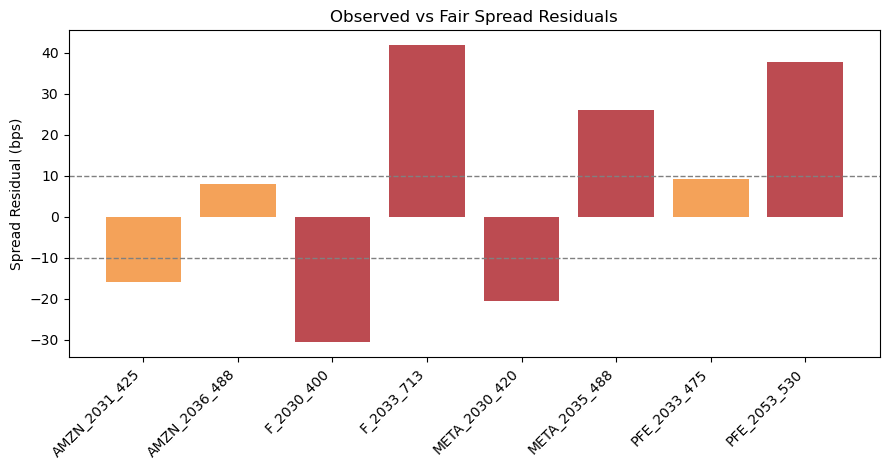

In [5]:
colors = {"Normal": "#4C956C", "Review": "#F4A259", "High Review": "#BC4B51"}
plt.figure(figsize=(9, 4.8))
plt.bar(
    evaluation_table["bond_id"],
    evaluation_table["spread_residual_bps"],
    color=[colors.get(flag, "#577590") for flag in evaluation_table["review_flag"]],
)
plt.axhline(10, linestyle="--", linewidth=1, color="gray")
plt.axhline(-10, linestyle="--", linewidth=1, color="gray")
plt.ylabel("Spread Residual (bps)")
plt.title("Observed vs Fair Spread Residuals")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

In [6]:
comp_table[["target_bond_id", "comp_bond_id", "comp_score", "comp_weight", "fair_spread"]]

,target_bond_id,comp_bond_id,comp_score,comp_weight,fair_spread
0,AMZN_2031_425,AMZN_2036_488,4.572345,4.572345,0.005692
1,AMZN_2031_425,META_2030_420,2.161889,2.161889,0.005692
2,AMZN_2031_425,PFE_2033_475,1.879887,1.879887,0.005692
3,AMZN_2036_488,AMZN_2031_425,4.572345,4.572345,0.005358
4,AMZN_2036_488,PFE_2033_475,2.174945,2.174945,0.005358
5,AMZN_2036_488,META_2035_488,1.837040,1.837040,0.005358
6,F_2030_400,F_2033_713,4.425468,4.425468,0.019408
7,F_2030_400,AMZN_2031_425,-0.559460,0.100000,0.019408
8,F_2030_400,META_2030_420,-1.221349,0.100000,0.019408
9,F_2033_713,F_2030_400,4.425468,4.425468,0.015907


A flagged bond here does not automatically mean the observed price is wrong. It means the bond deserves attention because the observed level is meaningfully different from the peer-supported fair level or because the peer support itself is not strong enough to be fully comfortable.